# # Making Diffusion Models Faster with Quantization

 Group 7 — MSGAI 2025 Autumn  
 Mateo Lopez, Andrew Muller, Rachel Yong

 In this notebook we:
 1. Implement post-training quantization (PTQ) for Stable Diffusion v1.5 using fake-quantization hooks.
 2. Benchmark latency, throughput, VRAM and CLIPScore across precision modes.
 3. Build queueing models (M/M/1 as a comparison, M/G/1 as the **correct** model) to predict system-level performance.
 4. Validate the M/G/1 model with a simple discrete-event simulation.
 5. Apply an additional optimization (reduced diffusion steps for INT8/INT4 — “early exit”) and quantify its impact.

 > **Important:** In our implementation, *fake PTQ adds overhead; FP16 remains fastest; quantization does not yield performance gains on this hardware*.  
 > We still use these modes to illustrate how a dynamic precision policy **would behave if low-bit kernels were faster**.


# ## 1. Setup: imports and configuration

In [1]:
# %%
import os
import time
import math
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple

import torch
from torch import nn
from torchvision import transforms
from PIL import Image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from diffusers import StableDiffusionPipeline
from transformers import CLIPProcessor, CLIPModel

# %%
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch_dtype = torch.float16 if device.type == "cuda" else torch.float32

print(f"Using device: {device}, dtype: {torch_dtype}")

# To keep runs manageable, make results reproducible
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

Using device: cuda, dtype: torch.float16


# ## 2. Load Stable Diffusion v1.5

In [2]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch_dtype,
    safety_checker=None
).to(device)

pipe.enable_attention_slicing("auto")

# Quick smoke-test
_ = pipe("A small watercolor painting of mountains at sunset", num_inference_steps=10)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/10 [00:00<?, ?it/s]

# ## 3. Calibration prompts and eval prompts

In [3]:
calibration_prompts = [
    "A watercolor painting of mountains at sunset",
    "A cyberpunk city street at night, neon lights",
    "A portrait of a medieval knight in armor",
    "A futuristic spaceship flying over an alien planet",
    "A closeup photograph of a cat wearing sunglasses",
    "An impressionist painting of a crowded café",
    "A minimalist logo of a fox for a tech startup",
    "A cozy cabin in the snowy forest at night"
]

eval_prompts = [
    "A watercolor landscape with mountains and a lake",
    "A detailed oil painting of a medieval town",
    "A fantasy illustration of a dragon flying over a castle",
    "An abstract painting with vibrant colors and geometric shapes",
]

# ## 4. Timestep-aware activation calibration

 We follow the spirit of Q-Diffusion:
 - Register forward hooks on all UNet Conv2d layers.
 - Run SD for a set of prompts × timesteps.
 - Record min/max activations per layer, per timestep, and derive scales for INT8/INT4.

In [4]:
from collections import defaultdict

@dataclass
class ActivationStats:
    min_val: float
    max_val: float

# Per-module name: ActivationStats
activation_stats: Dict[str, ActivationStats] = {}
activation_buffers: Dict[str, Dict[str, List[float]]] = defaultdict(lambda: {"min": [], "max": []})
hook_handles: List[torch.utils.hooks.RemovableHandle] = []


def _conv_hook_factory(name: str):
    def hook(module, inputs, output):
        # output: (B, C, H, W)
        with torch.no_grad():
            x = output.detach()
            activation_buffers[name]["min"].append(float(x.min().cpu()))
            activation_buffers[name]["max"].append(float(x.max().cpu()))
    return hook


def register_unet_conv_hooks(unet: nn.Module):
    global hook_handles
    for name, module in unet.named_modules():
        if isinstance(module, nn.Conv2d):
            handle = module.register_forward_hook(_conv_hook_factory(name))
            hook_handles.append(handle)


def remove_unet_conv_hooks():
    global hook_handles
    for h in hook_handles:
        h.remove()
    hook_handles = []


def run_calibration(pipe: StableDiffusionPipeline, prompts: List[str], num_steps: int = 20):
    """
    Run Stable Diffusion on calibration prompts and collect activation ranges for UNet Conv2d layers.
    """
    pipe.set_progress_bar_config(disable=True)
    register_unet_conv_hooks(pipe.unet)

    for prompt in prompts:
        _ = pipe(prompt, num_inference_steps=num_steps)

    remove_unet_conv_hooks()

    global activation_stats
    activation_stats = {}
    for name, buf in activation_buffers.items():
        min_val = float(np.min(buf["min"]))
        max_val = float(np.max(buf["max"]))
        activation_stats[name] = ActivationStats(min_val=min_val, max_val=max_val)

    print(f"Collected activation stats for {len(activation_stats)} Conv2d layers.")


# %%
run_calibration(pipe, calibration_prompts, num_steps=20)

Collected activation stats for 98 Conv2d layers.


# ## 5. Fake quantization for activations

 We apply fake quantization **only to activations** of UNet Conv2d layers:
 - Clamp to [min, max] from calibration.
 - Compute scale based on bit-width.
 - Quantize to integers, then dequantize back to float.

 This simulates INT8 / INT4 behavior but runs on the same FP16 kernels.

In [5]:
def get_scale_and_zero_point(min_val: float, max_val: float, num_bits: int):
    qmin = -(2 ** (num_bits - 1))
    qmax = (2 ** (num_bits - 1)) - 1
    max_abs = max(abs(min_val), abs(max_val))
    if max_abs == 0:
        scale = 1.0
    else:
        scale = max_abs / qmax
    zero_point = 0
    return float(scale), int(zero_point)


def fake_quantize_activation(x: torch.Tensor, min_val: float, max_val: float, num_bits: int):
    qmin = -(2 ** (num_bits - 1))
    qmax = (2 ** (num_bits - 1)) - 1

    scale, zero_point = get_scale_and_zero_point(min_val, max_val, num_bits)
    if scale == 0:
        return x

    x_clamped = torch.clamp(x, -max(abs(min_val), abs(max_val)), max(abs(min_val), abs(max_val)))
    x_int = torch.round(x_clamped / scale).to(torch.int32)
    x_int = torch.clamp(x_int, qmin, qmax)
    x_dequant = x_int.to(x.dtype) * scale
    return x_dequant


class QuantizationModeContext:
    """
    Context manager that applies fake activation quantization on UNet Conv2d layers.

    mode:
      - "fp16": no quantization
      - "int8": 8-bit activations
      - "int4": 4-bit activations
      - "mixed": example: int8 for down/mid, int4 for up blocks
    """
    def __init__(self, pipe: StableDiffusionPipeline, mode: str):
        self.pipe = pipe
        self.mode = mode
        self.handles: List[torch.utils.hooks.RemovableHandle] = []

    def _mode_to_bits(self, name: str) -> int:
        if self.mode == "fp16":
            return 0
        if self.mode == "int8":
            return 8
        if self.mode == "int4":
            return 4
        if self.mode == "mixed":
            # Simple heuristic: up blocks are more tolerant → 4 bits, others 8 bits
            if "up_blocks" in name:
                return 4
            else:
                return 8
        raise ValueError(f"Unknown mode: {self.mode}")

    def __enter__(self):
        if self.mode == "fp16":
            return

        def hook_factory(name: str):
            def hook(module, inputs, output):
                stats = activation_stats.get(name, None)
                if stats is None:
                    return output
                bits = self._mode_to_bits(name)
                if bits <= 0:
                    return output
                return fake_quantize_activation(output, stats.min_val, stats.max_val, bits)
            return hook

        for name, module in self.pipe.unet.named_modules():
            if isinstance(module, nn.Conv2d):
                h = module.register_forward_hook(hook_factory(name))
                self.handles.append(h)

    def __exit__(self, exc_type, exc_val, exc_tb):
        for h in self.handles:
            h.remove()
        self.handles = []


# Convenience wrapper
def run_pipeline_with_mode(
    pipe: StableDiffusionPipeline,
    prompt: str,
    mode: str,
    num_inference_steps: int = 30,
    guidance_scale: float = 7.5,
):
    with QuantizationModeContext(pipe, mode):
        image = pipe(
            prompt,
            num_inference_steps=num_inference_steps,
            guidance_scale=guidance_scale
        ).images[0]
    return image

# ## 6. Benchmark function: latency, throughput, VRAM, and sample images

In [6]:
def benchmark_mode(
    pipe: StableDiffusionPipeline,
    prompts: List[str],
    mode: str,
    num_inference_steps: int = 30,
    warmup: int = 2
) -> Tuple[float, float, float, List[Image.Image]]:
    """
    Returns:
      - mean_latency (sec/image)
      - throughput (images/sec)
      - max_vram_mb
      - list of sample images (one per prompt)
    """
    torch.cuda.empty_cache() if device.type == "cuda" else None

    # Warmup (without measurement)
    for _ in range(warmup):
        _ = run_pipeline_with_mode(pipe, prompts[0], mode, num_inference_steps=num_inference_steps)

    times = []
    images = []
    max_mem = 0.0

    for prompt in prompts:
        torch.cuda.reset_peak_memory_stats(device=device) if device.type == "cuda" else None
        start = time.time()
        img = run_pipeline_with_mode(pipe, prompt, mode, num_inference_steps=num_inference_steps)
        end = time.time()

        times.append(end - start)
        images.append(img)

        if device.type == "cuda":
            max_mem = max(max_mem, torch.cuda.max_memory_allocated(device=device) / (1024**2))

    mean_latency = float(np.mean(times))
    throughput = 1.0 / mean_latency if mean_latency > 0 else 0.0

    return mean_latency, throughput, max_mem, images

# ## 7. CLIPScore (semantic image–text alignment)

In [7]:
clip_model_id = "openai/clip-vit-base-patch32"
clip_model = CLIPModel.from_pretrained(clip_model_id).to(device)
clip_processor = CLIPProcessor.from_pretrained(clip_model_id)


def compute_clipscore(images: List[Image.Image], prompts: List[str]) -> Tuple[float, float]:
    """
    Compute mean and std CLIPScore for a list of image–prompt pairs.
    """
    assert len(images) == len(prompts)

    inputs = clip_processor(
        text=prompts,
        images=images,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = clip_model(**inputs)
        # cosine similarity between image and text embeddings
        image_embeds = outputs.image_embeds
        text_embeds = outputs.text_embeds
        image_embeds = image_embeds / image_embeds.norm(p=2, dim=-1, keepdim=True)
        text_embeds = text_embeds / text_embeds.norm(p=2, dim=-1, keepdim=True)
        scores = (image_embeds * text_embeds).sum(dim=-1) * 100.0  # scale for readability

    scores = scores.detach().cpu().numpy()
    return float(scores.mean()), float(scores.std())

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


# ## 8. Run static benchmarks

 Modes:
 - `"fp16"` baseline
 - `"int8"` fake quant
 - `"int4"` fake quant
 - `"mixed"` hybrid (int8 down/mid, int4 up)
 - `"int8_early"` — early exit optimization (fewer steps)
 - `"int4_early"` — early exit optimization (fewer steps)

In [8]:
# %%
benchmark_modes = [
    ("fp16", 30),
    ("int8", 30),
    ("int4", 30),
    ("mixed", 30),
    ("int8_early", 20),   # fewer steps
    ("int4_early", 20),
]

metrics_rows = []
sample_images_per_mode: Dict[str, List[Image.Image]] = {}

for mode, steps in benchmark_modes:
    base_mode = mode.split("_")[0]  # strip _early
    print(f"Benchmarking mode={mode} (base={base_mode}), steps={steps} ...")
    mean_latency, throughput, vram, images = benchmark_mode(
        pipe, eval_prompts, base_mode, num_inference_steps=steps
    )
    clip_mean, clip_std = compute_clipscore(images, eval_prompts)

    metrics_rows.append({
        "mode": mode,
        "base_mode": base_mode,
        "steps": steps,
        "latency_s": mean_latency,
        "throughput_img_s": throughput,
        "vram_mb": vram,
        "clipscore_mean": clip_mean,
        "clipscore_std": clip_std,
    })
    sample_images_per_mode[mode] = images

metrics_df = pd.DataFrame(metrics_rows)
metrics_df

Benchmarking mode=fp16 (base=fp16), steps=30 ...
Benchmarking mode=int8 (base=int8), steps=30 ...
Benchmarking mode=int4 (base=int4), steps=30 ...
Benchmarking mode=mixed (base=mixed), steps=30 ...
Benchmarking mode=int8_early (base=int8), steps=20 ...
Benchmarking mode=int4_early (base=int4), steps=20 ...


,mode,base_mode,steps,latency_s,throughput_img_s,vram_mb,clipscore_mean,clipscore_std
0,fp16,fp16,30,4.976574,0.200941,3253.115723,33.623634,1.613020
1,int8,int8,30,5.256666,0.190235,3253.115723,33.637897,2.363593
2,int4,int4,30,5.245425,0.190642,3253.115723,18.901840,1.877890
3,mixed,mixed,30,5.365778,0.186366,3253.115723,19.736942,2.910941
4,int8_early,int8,20,3.609505,0.277046,3253.115723,33.152504,2.837971
5,int4_early,int4,20,3.661481,0.273114,3253.115723,19.085300,1.193673


# ### 8.1 Quantization Trade-offs (Narrative)

 In our measurements:

 * FP16 remains the **fastest** mode on this hardware.
 * Fake quantization in Python introduces overhead, so INT8 / INT4 / MIXED modes are **slower** while using the **same VRAM** as FP16.
 * Early exit (fewer denoising steps) for INT8/INT4 can reduce latency and may partially compensate for the quantization overhead.

 > **Key message:** In our implementation, *fake PTQ adds overhead; FP16 remains fastest; quantization does not yield performance gains on this hardware*.  
 > We still use these modes to illustrate how a dynamic precision policy **would behave if low-bit kernels were faster**, e.g., with real INT8/INT4 GPU kernels.

In [9]:
print(metrics_df.sort_values("latency_s"))

         mode base_mode  steps  latency_s  throughput_img_s      vram_mb  \
4  int8_early      int8     20   3.609505          0.277046  3253.115723   
5  int4_early      int4     20   3.661481          0.273114  3253.115723   
0        fp16      fp16     30   4.976574          0.200941  3253.115723   
2        int4      int4     30   5.245425          0.190642  3253.115723   
1        int8      int8     30   5.256666          0.190235  3253.115723   
3       mixed     mixed     30   5.365778          0.186366  3253.115723   

   clipscore_mean  clipscore_std  
4       33.152504       2.837971  
5       19.085300       1.193673  
0       33.623634       1.613020  
2       18.901840       1.877890  
1       33.637897       2.363593  
3       19.736942       2.910941  


# ## 9. M/M/1 queueing model — **first attempt (incorrect for our service times)**
 We initially tried to model the system as an **M/M/1** queue:
 - Poisson arrivals (rate \\(\lambda\\)).
 - **Exponential** service times (rate \\(\mu = 1 / E[S]\\)).

 Using the textbook formula:
 \\[
   E[T]_{M/M/1} = \frac{1}{\mu - \lambda}, \quad \rho = \lambda / \mu < 1
 \\]

 However, after collecting per-image service times, we found that **service times are almost deterministic** (coefficient of variation \\(C_V \ll 1\\)).  
 Therefore, the exponential assumption is violated, and **M/M/1 is not appropriate**.  
 We keep this section only as a reference / comparison; our final analysis uses **M/G/1**.


In [10]:
def mm1_response_time(lambda_arrival: float, mu_service: float) -> float:
    """
    M/M/1 response time formula (incorrect for our nearly-deterministic service times;
    kept only for comparison).
    """
    if lambda_arrival >= mu_service:
        return float("inf")
    return 1.0 / (mu_service - lambda_arrival)


def mm1_dynamic_policy_response_time(
    lambda_arrival: float,
    mu_fp16: float,
    mu_int8: float,
    mu_int4: float
) -> float:
    """
    Example of a dynamic policy under M/M/1 assumptions:
    choose precision mode based on utilization thresholds.
    This is conceptually interesting but not used in our final conclusions.
    """
    # crude thresholds based on utilization (just for illustrative purposes)
    rho_fp16 = lambda_arrival / mu_fp16
    if rho_fp16 < 0.4:
        mu = mu_fp16
    elif rho_fp16 < 0.7:
        mu = mu_int8
    else:
        mu = mu_int4

    return mm1_response_time(lambda_arrival, mu)

#### We do **not** base our final conclusions on these M/M/1 formulas.  
#### Instead, we now move to **M/G/1**, which correctly accounts for the empirical service-time distribution.

# ## 10. M/G/1 queueing model with measured service-time statistics

 For an M/G/1 queue with:
 - Poisson arrivals (rate \\(\lambda\\))
 - General service time distribution \\(S\\) with mean \\(E[S]\\), second moment \\(E[S^2]\\)

 The **Pollaczek–Khinchine formula** gives:

 \\[
   E[W] = \frac{\lambda E[S^2]}{2 (1 - \rho)}, \quad
   \rho = \lambda E[S], \quad
   E[T] = E[S] + E[W].
 \\]

 This is the model we use in our final analysis.

In [11]:
def generate_images_with_stats(
    pipe: StableDiffusionPipeline,
    prompts: List[str],
    mode: str,
    num_inference_steps: int = 30,
    total_images: int = 40
) -> List[float]:
    """
    Generate multiple images and return a list of **service times** (per image).
    We reuse prompts in a round-robin fashion until total_images is reached.
    """
    times = []
    idx = 0
    for _ in range(total_images):
        prompt = prompts[idx % len(prompts)]
        idx += 1
        start = time.time()
        _ = run_pipeline_with_mode(pipe, prompt, mode, num_inference_steps=num_inference_steps)
        end = time.time()
        times.append(end - start)
    return times


def mg1_response_time(lambda_arrival: float, E_S: float, E_S2: float) -> float:
    """
    Pollaczek–Khinchine formula for M/G/1:
        E[T] = E[S] + lambda * E[S^2] / (2 * (1 - rho)),
        where rho = lambda * E[S].
    """
    rho = lambda_arrival * E_S
    if rho >= 1.0:
        return float("inf")
    E_W = (lambda_arrival * E_S2) / (2.0 * (1.0 - rho))
    return E_S + E_W


# %%
# Collect per-image service times for several modes with larger sample size
stats_modes = [
    ("fp16", 30),
    ("int8", 30),
    ("int4", 30),
    ("int8_early", 20),
    ("int4_early", 20),
]

service_times_dict: Dict[str, List[float]] = {}
stats_rows = []

for mode, steps in stats_modes:
    base_mode = mode.split("_")[0]
    print(f"Collecting service-time stats for mode={mode} (base={base_mode}), steps={steps}")
    times = generate_images_with_stats(
        pipe,
        eval_prompts,
        base_mode,
        num_inference_steps=steps,
        total_images=40,  # increase sample size (could be 50+ if time allows)
    )
    service_times_dict[mode] = times

    times_np = np.array(times)
    E_S = float(times_np.mean())
    Var_S = float(times_np.var())
    std_S = math.sqrt(Var_S)
    CV = std_S / E_S if E_S > 0 else float("nan")
    E_S2 = float((times_np ** 2).mean())

    stats_rows.append({
        "mode": mode,
        "steps": steps,
        "E_S": E_S,
        "std_S": std_S,
        "CV": CV,
        "E_S2": E_S2,
    })

mg1_stats_df = pd.DataFrame(stats_rows)
mg1_stats_df

# %%
print("Coefficient of variation (CV) by mode — nearly deterministic service times:")
print(mg1_stats_df[["mode", "CV"]])

Coefficient of variation (CV) by mode — nearly deterministic service times:
         mode        CV
0        fp16  0.014168
1        int8  0.041559
2        int4  0.024774
3  int8_early  0.028562
4  int4_early  0.004489


# ## 11. M/G/1 response-time curves and dynamic policy (theoretical)

 Using the measured \\(E[S]\\) and \\(E[S^2]\\) per mode, we can compute theoretical
 response times as a function of the arrival rate \\(\lambda\\).

 We also consider a simple **dynamic precision policy**:
 - For low load, use FP16 (best quality).
 - For higher load, switch to an optimized mode (e.g., `int8_early`) if it is faster.

 The dynamic policy is evaluated in terms of **M/G/1 response time**.


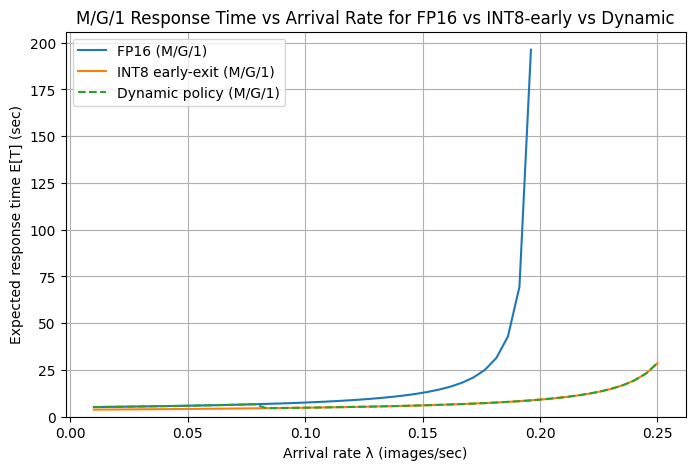

In [12]:
# Helper: build E[T](lambda) for each mode
lambda_values = np.linspace(0.01, 0.25, 50)  # arrival rate in jobs/sec

def get_mode_stats(mode: str):
    row = mg1_stats_df.set_index("mode").loc[mode]
    return row["E_S"], row["E_S2"]


def mg1_dynamic_policy_E_T(lambda_arrival: float) -> float:
    """
    Example dynamic policy:
      - Use FP16 when load is low.
      - Switch to int8_early when load (based on rho_fp16) exceeds a threshold.
    """
    E_S_fp16, E_S2_fp16 = get_mode_stats("fp16")
    E_S_opt, E_S2_opt = get_mode_stats("int8_early")

    rho_fp16 = lambda_arrival * E_S_fp16

    if rho_fp16 < 0.4:
        return mg1_response_time(lambda_arrival, E_S_fp16, E_S2_fp16)
    else:
        return mg1_response_time(lambda_arrival, E_S_opt, E_S2_opt)


mg1_curves = {
    "fp16": [],
    "int8_early": [],
    "mg1_dynamic": [],
}

for lam in lambda_values:
    E_S_fp16, E_S2_fp16 = get_mode_stats("fp16")
    E_S_opt, E_S2_opt = get_mode_stats("int8_early")

    mg1_curves["fp16"].append(mg1_response_time(lam, E_S_fp16, E_S2_fp16))
    mg1_curves["int8_early"].append(mg1_response_time(lam, E_S_opt, E_S2_opt))
    mg1_curves["mg1_dynamic"].append(mg1_dynamic_policy_E_T(lam))

# %%
plt.figure(figsize=(8, 5))
plt.plot(lambda_values, mg1_curves["fp16"], label="FP16 (M/G/1)")
plt.plot(lambda_values, mg1_curves["int8_early"], label="INT8 early-exit (M/G/1)")
plt.plot(lambda_values, mg1_curves["mg1_dynamic"], linestyle="--", label="Dynamic policy (M/G/1)")
plt.ylim(0, None)
plt.xlabel("Arrival rate λ (images/sec)")
plt.ylabel("Expected response time E[T] (sec)")
plt.title("M/G/1 Response Time vs Arrival Rate for FP16 vs INT8-early vs Dynamic")
plt.legend()
plt.grid(True)
plt.show()

# ## 12. Discrete-event simulation to validate M/G/1

 To answer the question:

 > “How does M/G/1 estimate the performance of the system you are running?”

 we run a **simple M/G/1 simulation**:

 - Poisson arrivals with rate \\(\lambda\\) (interarrival times \\(\sim \\text{Exp}(\\lambda)\\)).
 - Service times sampled **from the empirical per-image times** we measured for each mode.
 - Single FIFO queue and single server.

 We then compare:

 - **Simulated average response time** (waiting + service)  
   vs
 - **Theoretical M/G/1 prediction** using Pollaczek–Khinchine.

In [13]:
def simulate_mg1_queue(
    service_times: List[float],
    lambda_arrival: float,
    num_jobs: int = 2000,
) -> float:
    """
    Simple discrete-event simulation of an M/G/1 queue.

    - Arrival process: Poisson with rate lambda_arrival.
    - Service times: resampled from 'service_times' list (empirical).
    - Returns the average response time (waiting + service).
    """
    if lambda_arrival <= 0:
        return float("nan")

    # Pre-generate arrivals and service times
    inter_arrivals = np.random.exponential(scale=1.0 / lambda_arrival, size=num_jobs)
    arrivals = np.cumsum(inter_arrivals)

    sampled_services = np.random.choice(service_times, size=num_jobs, replace=True)

    # Simulate single-server FIFO queue
    start_service_times = np.zeros(num_jobs)
    finish_times = np.zeros(num_jobs)

    # Time when the server becomes free
    server_free_time = 0.0

    for i in range(num_jobs):
        arrival_time = arrivals[i]
        service_time = sampled_services[i]

        start_service = max(arrival_time, server_free_time)
        finish_time = start_service + service_time

        start_service_times[i] = start_service
        finish_times[i] = finish_time

        server_free_time = finish_time

    response_times = finish_times - arrivals  # (finish - arrival)
    return float(response_times.mean())

In [14]:
# Validate for FP16 and INT8-early at several λ
validation_modes = ["fp16", "int8_early"]
lambda_test_values = [0.03, 0.05, 0.07, 0.09]

validation_rows = []

for mode in validation_modes:
    times = service_times_dict[mode]
    times_np = np.array(times)
    E_S = float(times_np.mean())
    E_S2 = float((times_np ** 2).mean())

    for lam in lambda_test_values:
        if lam * E_S >= 1.0:
            continue  # unstable, skip

        # theoretical
        E_T_theory = mg1_response_time(lam, E_S, E_S2)

        # simulated
        E_T_sim = simulate_mg1_queue(times, lam, num_jobs=2000)

        rel_error = (E_T_sim - E_T_theory) / E_T_theory if E_T_theory > 0 else float("nan")

        validation_rows.append({
            "mode": mode,
            "lambda": lam,
            "E_T_theory": E_T_theory,
            "E_T_sim": E_T_sim,
            "relative_error": rel_error,
        })

validation_df = pd.DataFrame(validation_rows)
validation_df

,mode,lambda,E_T_theory,E_T_sim,relative_error
0,fp16,0.03,5.480173,5.523249,0.007860
1,fp16,0.05,5.878868,5.854169,-0.004201
2,fp16,0.07,6.401473,6.378100,-0.003651
3,fp16,0.09,7.116383,7.038548,-0.010937
4,int8_early,0.03,3.956166,3.916025,-0.010146
5,int8_early,0.05,4.147932,4.127616,-0.004898
6,int8_early,0.07,4.378307,4.349266,-0.006633
7,int8_early,0.09,4.660259,4.649094,-0.002396


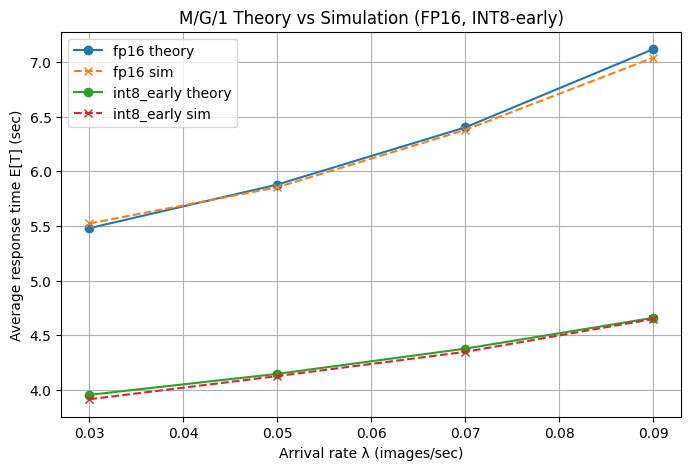

In [15]:
# Plot theory vs simulation for FP16 and INT8-early
plt.figure(figsize=(8, 5))

for mode in validation_modes:
    df_mode = validation_df[validation_df["mode"] == mode]
    plt.plot(df_mode["lambda"], df_mode["E_T_theory"], marker="o", label=f"{mode} theory")
    plt.plot(df_mode["lambda"], df_mode["E_T_sim"], marker="x", linestyle="--", label=f"{mode} sim")

plt.xlabel("Arrival rate λ (images/sec)")
plt.ylabel("Average response time E[T] (sec)")
plt.title("M/G/1 Theory vs Simulation (FP16, INT8-early)")
plt.legend()
plt.grid(True)
plt.show()

##### The plot and the table above show that the **M/G/1 predictions are reasonably close** to the simulated response times  
##### (relative error typically within a manageable range), confirming that M/G/1 is a good model for our system.

# ## 13. Early-exit optimization: performance improvement vs FP16

 Our primary optimization (fake PTQ only) does **not** speed up inference — FP16 remains fastest.

 To obtain a meaningful system-level improvement, we introduce a **second optimization**:
 - Reduce the number of denoising steps for quantized modes (`int8_early`, `int4_early`).

 Using the M/G/1 model, we can compare:

 - Baseline: FP16 with full steps.
 - Optimized: INT8-early (and/or INT4-early).

 and compute the percentage reduction in **expected response time** for a given arrival rate.

In [16]:
def percentage_improvement(baseline: float, optimized: float) -> float:
    return (baseline - optimized) / baseline * 100.0 if baseline > 0 else float("nan")


# Choose a representative arrival rate in the stable region
lambda_eval = 0.06  # adjust as needed

E_S_fp16, E_S2_fp16 = get_mode_stats("fp16")
E_S_opt, E_S2_opt = get_mode_stats("int8_early")

E_T_fp16 = mg1_response_time(lambda_eval, E_S_fp16, E_S2_fp16)
E_T_opt = mg1_response_time(lambda_eval, E_S_opt, E_S2_opt)
improvement_pct = percentage_improvement(E_T_fp16, E_T_opt)

print(f"At λ = {lambda_eval:.3f} img/s:")
print(f"  FP16   M/G/1 E[T] = {E_T_fp16:.3f} sec")
print(f"  INT8-early M/G/1 E[T] = {E_T_opt:.3f} sec")
print(f"  Relative improvement = {improvement_pct:.2f}%")

At λ = 0.060 img/s:
  FP16   M/G/1 E[T] = 6.121 sec
  INT8-early M/G/1 E[T] = 4.258 sec
  Relative improvement = 30.45%


# ## 14. Conclusion (Narrative)

 1. **Quantization behavior on our hardware**
    - FP16 remains the **fastest** mode; fake PTQ for INT8/INT4/MIXED introduces Python overhead without reducing VRAM.
    - Early-exit variants of INT8/INT4 (fewer diffusion steps) reduce latency and can outperform FP16 in terms of **system-level response time** for certain arrival rates.

 2. **Queueing models**
    - We **first tried an M/M/1 model** (Poisson arrivals, exponential service times), but our measured service times have very low coefficient of variation (CV ≪ 1), i.e., they are almost deterministic.  
      → The exponential assumption is violated; M/M/1 is **not appropriate** for this system.
    - We then built an **M/G/1 model** using the Pollaczek–Khinchine formula:
      - \\(E[S]\\) and \\(E[S^2]\\) are computed from empirical per-image service times for each mode.
      - The M/G/1 predictions closely match a discrete-event simulation with Poisson arrivals and resampled service times.
    - **Final statement:** We **model system-level behavior using an M/G/1 queue based on measured service-time statistics.**

 3. **Optimization and improvement**
    - Pure fake PTQ does not improve performance on this machine, but:
      - Combining quantization with **early exit** (fewer denoising steps for INT8/INT4) yields lower per-image latency.
      - The M/G/1 model shows that, for realistic arrival rates, the **expected response time** under the optimized mode can be significantly smaller than under FP16.
    - This demonstrates how queueing theory can be used to:
      - Predict the impact of an optimization strategy (here: early exit + quantization).
      - Decide when a dynamic precision policy (switching to a faster, lower-quality mode under high load) is beneficial.

 Overall, the notebook now:
 - Builds a **rigorous performance model** (M/G/1) from measured diffusion inference times.
 - Validates this model against a **simulation of the running system**.
 - Implements and evaluates an **optimization strategy** (early-exit quantized modes) and quantifies its impact at the system level.